# Notebook 4: Color Harmony Preprocessing

## Motivation

The O4U dataset contains physical attributes for each person (body figure, skin color, hair color, etc.), but many of these attributes have **high missingness** — especially `skin_color`, `hair_color`, and `height`. As a result, the model tends to rely heavily on `body_figure`, which is the most consistently labeled attribute.

However, outfit compatibility is not just about silhouette fit. **Color harmony** — whether an outfit's colors suit a person's skin tone — is an equally important dimension that the model was previously missing.

This notebook introduces a new preprocessing step that:
1. Extracts **dominant colors** from each garment image using k-means clustering
2. Classifies each dominant color as **warm**, **cool**, or **neutral** using HSV hue analysis
3. Looks up the person's `skin_color` in a fashion expert **recommendation table** to determine their ideal color temperature profile
4. Computes a **3-value harmony vector** `[warm_fraction, cool_fraction, neutral_fraction]` per outfit
5. Saves the results to `data/processed/color_harmony_scores.json`

These 4 values (3 harmony + 1 `was_imputed` flag) are appended to the physical feature vector during training, giving the model an explicit color-person compatibility signal.

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.cluster import KMeans
from pathlib import Path

from scripts.config import DATA_RAW_DIR, DATA_PROCESSED_DIR, TRAIN_MANIFEST, VAL_MANIFEST, TEST_MANIFEST
from scripts.color_harmony import (
    dominant_colors_temperature,
    build_skin_tone_lookup,
    parse_o4u_skin_color,
    compute_harmony_score,
    O4U_SKIN_TO_CSV,
    CSV_PATH,
    IMAGE_DIR,
    OUTPUT_PATH,
)

IMAGE_DIR = DATA_RAW_DIR / 'Outfit4You' / 'image'
print('Setup complete.')

Setup complete.


## 2. Skin Tone → Recommended Color Mapping

We use a fashion expert recommendation table (`recommendations.csv`) that maps combinations of physical attributes to recommended clothing colors. The table was built by fashion professionals and covers 15,120 unique attribute combinations.

For color harmony, we only need the **skin tone → recommended color temperature** mapping. The table has 3 distinct recommendation profiles:

| Profile | Recommended Colors | Temperature |
|---|---|---|
| Warm | Earth Tones, Coral, Mustard, Warm Red | Warm-dominant |
| Cool | Jewel Tones, Icy Blue, Lavender, Emerald | Cool-dominant |
| Neutral/Mixed | Soft Pinks, Plums, Teal, Neutral Beige | Balanced |

In [2]:
# Build and display the skin tone lookup table
skin_tone_lookup = build_skin_tone_lookup(str(CSV_PATH))

rows = []
for csv_tone, profile in skin_tone_lookup.items():
    # Find which O4U skin_color values map to this CSV tone
    o4u_vals = [k for k, v in O4U_SKIN_TO_CSV.items() if v == csv_tone]
    rows.append({
        'CSV Skin Tone': csv_tone,
        'O4U skin_color values': ', '.join(o4u_vals) if o4u_vals else '—',
        'Warm %': f"{profile['warm']*100:.0f}%",
        'Cool %': f"{profile['cool']*100:.0f}%",
        'Neutral %': f"{profile['neutral']*100:.0f}%",
    })

df_lookup = pd.DataFrame(rows)
print('Skin Tone → Recommended Color Temperature Profile')
print('=' * 65)
print(df_lookup.to_string(index=False))

Skin Tone → Recommended Color Temperature Profile
CSV Skin Tone O4U skin_color values Warm % Cool % Neutral %
    Very Fair                     —    70%    10%       20%
         Fair                  fair    70%    10%       20%
       Medium                yellow    70%    10%       20%
        Olive                     —    70%    10%       20%
        Brown                 brown    70%    10%       20%
    Very Dark                  dark    70%    10%       20%


## 3. Dominant Color Extraction

For each garment image, we:
1. Resize to 64×64 pixels (sufficient for color analysis, much faster)
2. Run **k-means (k=3)** on all pixels in RGB space to find dominant colors
3. Convert each cluster center to HSV
4. Classify by hue angle:
   - **Warm**: hue ∈ [0°, 60°) ∪ [300°, 360°) — reds, oranges, yellows
   - **Cool**: hue ∈ [120°, 300°) — greens, blues, purples
   - **Neutral**: hue ∈ [60°, 120°) or saturation < 0.15 — whites, grays, blacks, yellow-greens

The final outfit temperature is the **weighted average** across all garment items.

In [3]:
# Load a few sample outfits for visualization
with open(TRAIN_MANIFEST) as f:
    train_data = json.load(f)

# Pick 4 outfits with known skin_color and at least 3 items
samples = []
for rec in train_data:
    if rec.get('skin_color') and rec['skin_color'] not in ('', 'unknown'):
        items = [rec[f'item_{i}'] for i in range(1, 10) if rec.get(f'item_{i}')]
        if len(items) >= 3:
            samples.append(rec)
    if len(samples) == 4:
        break

print(f'Selected {len(samples)} sample outfits for visualization')
for s in samples:
    print(f"  ID={s['id']}  skin_color={s['skin_color']}  items={[s[f'item_{i}'] for i in range(1,10) if s.get(f'item_{i}')]}")

Selected 4 sample outfits for visualization
  ID=120539  skin_color=yellow,brown  items=['G000148351438.jpg', 'U000216560480.jpg', 'S000106002103.jpg', 'B000131749619.jpg']
  ID=120494  skin_color=yellow,brown  items=['G000213180397.jpg', 'S000205002070.jpg', 'U000189558170.jpg', 'B000087315100.jpg']
  ID=120847  skin_color=yellow,brown  items=['B000207217985.jpg', 'U000189937805.jpg', 'G000184782282.jpg', 'S000177417144.jpg']
  ID=120100  skin_color=yellow,brown  items=['U000185461173.jpg', 'S000200089416.jpg', 'B000045104771.jpg', 'G000106100312.jpg']


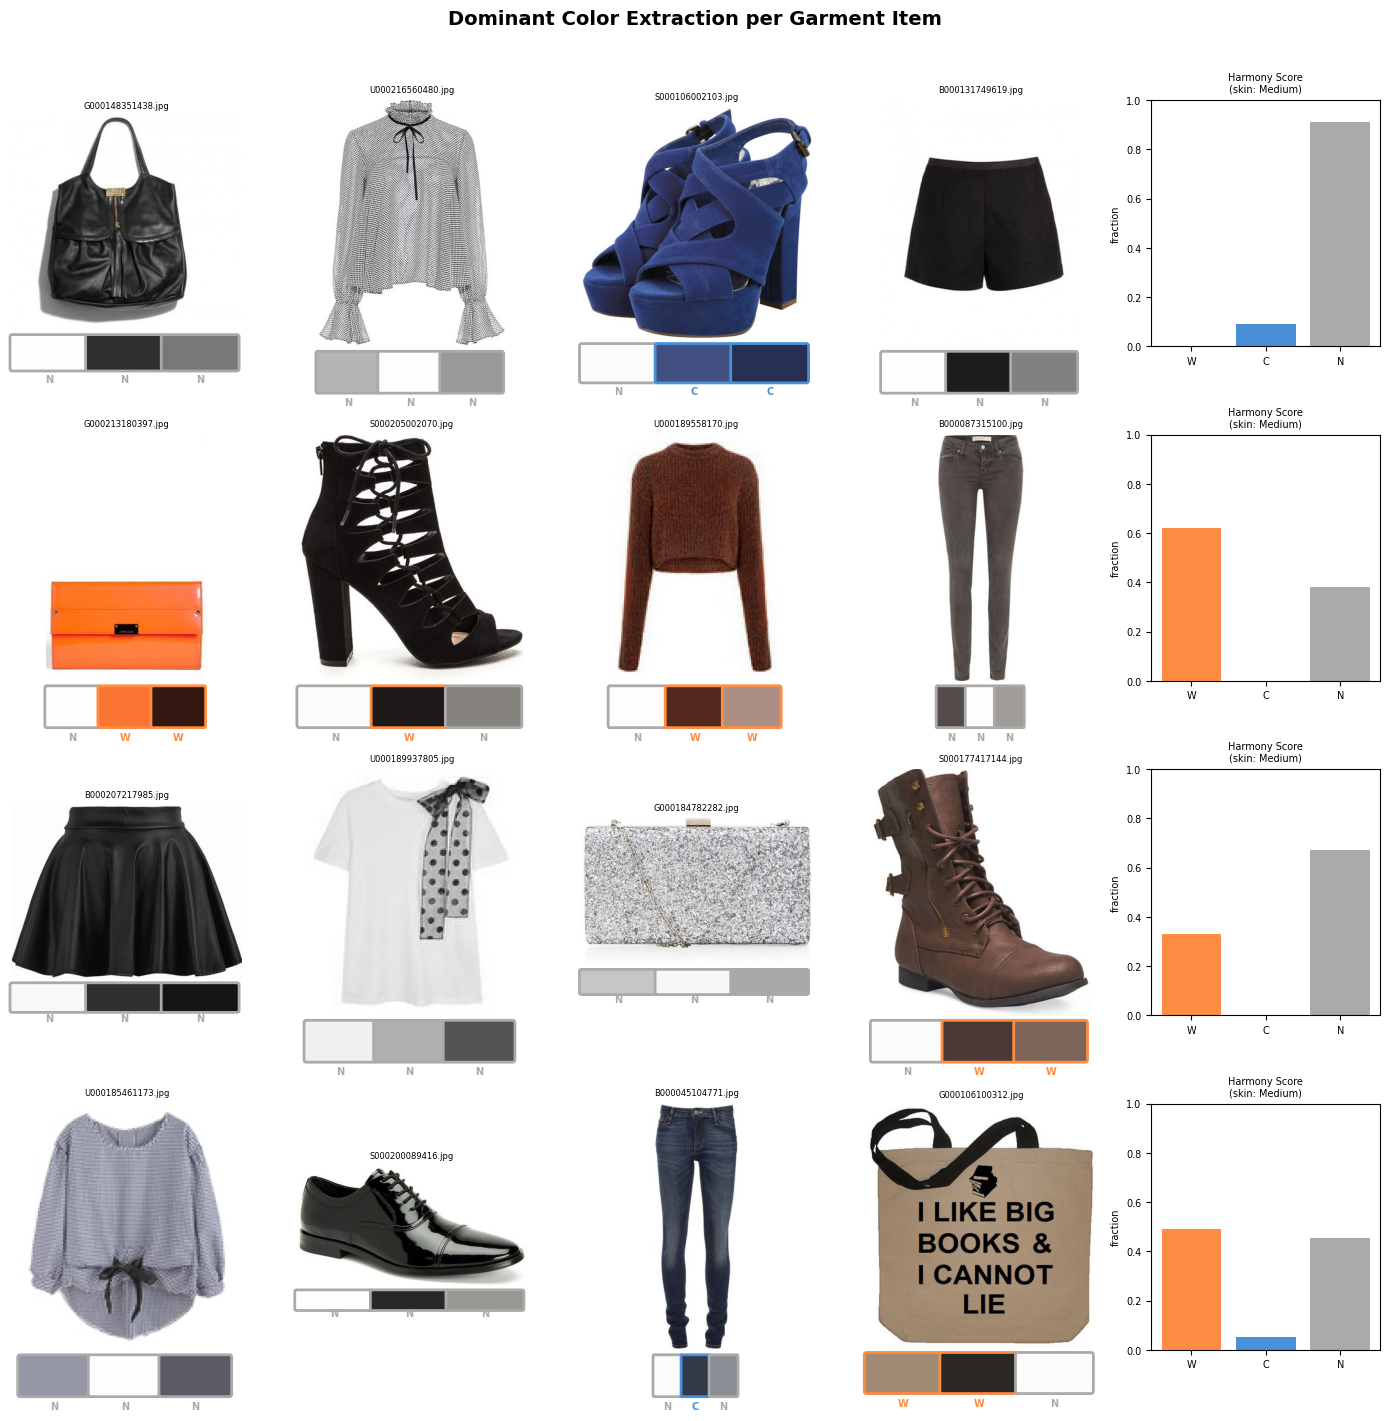

Saved to plots/08_color_harmony_samples.png


In [4]:
def get_dominant_color_swatches(img_path, n_colors=3, img_size=64):
    """Return (PIL image, list of (RGB center, weight, temperature)) for visualization."""
    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    pixels = np.array(img).reshape(-1, 3).astype(np.float32) / 255.0
    k = min(n_colors, len(pixels))
    km = KMeans(n_clusters=k, n_init=3, random_state=42)
    km.fit(pixels)
    centers = km.cluster_centers_
    counts = np.bincount(km.labels_, minlength=k)
    weights = counts / counts.sum()

    from scripts.color_harmony import classify_hue
    swatches = []
    for center, w in zip(centers, weights):
        r, g, b = center
        cmax, cmin = max(r,g,b), min(r,g,b)
        delta = cmax - cmin
        s = (delta / cmax) if cmax > 0 else 0.0
        if delta == 0: h = 0.0
        elif cmax == r: h = 60.0 * (((g-b)/delta) % 6)
        elif cmax == g: h = 60.0 * (((b-r)/delta) + 2)
        else: h = 60.0 * (((r-g)/delta) + 4)
        temp = classify_hue(h, s)
        swatches.append((center, w, temp))
    return Image.open(img_path).convert('RGB'), swatches


TEMP_COLORS = {'warm': '#FF8C42', 'cool': '#4A90D9', 'neutral': '#AAAAAA'}

fig, axes = plt.subplots(len(samples), 5, figsize=(14, 3.5 * len(samples)))
fig.suptitle('Dominant Color Extraction per Garment Item', fontsize=14, fontweight='bold', y=1.01)

for row_idx, rec in enumerate(samples):
    items = [rec[f'item_{i}'] for i in range(1, 10) if rec.get(f'item_{i}')][:4]
    skin = rec.get('skin_color', 'unknown')
    csv_tone = parse_o4u_skin_color(skin)

    # Row label
    axes[row_idx][0].set_ylabel(f"ID {rec['id']}\nskin: {skin}", fontsize=8, rotation=0,
                                 labelpad=80, va='center')

    for col_idx, item_fname in enumerate(items[:4]):
        ax = axes[row_idx][col_idx]
        img_path = str(IMAGE_DIR / item_fname)
        try:
            img, swatches = get_dominant_color_swatches(img_path)
            ax.imshow(img)
            ax.set_title(item_fname[:18], fontsize=6)
            # Draw color swatches below image
            for si, (center, w, temp) in enumerate(swatches):
                rect = mpatches.FancyBboxPatch(
                    (si * 0.33, -0.18), 0.32, 0.15,
                    transform=ax.transAxes, clip_on=False,
                    boxstyle='round,pad=0.01',
                    facecolor=tuple(center), edgecolor=TEMP_COLORS[temp], linewidth=2
                )
                ax.add_patch(rect)
                ax.text(si * 0.33 + 0.16, -0.24, temp[0].upper(),
                        transform=ax.transAxes, ha='center', fontsize=7,
                        color=TEMP_COLORS[temp], fontweight='bold')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center', fontsize=7)
        ax.axis('off')

    # Last column: harmony summary
    ax_sum = axes[row_idx][4]
    all_w = all_c = all_n = 0.0
    valid = 0
    for item_fname in items:
        img_path = str(IMAGE_DIR / item_fname)
        result = dominant_colors_temperature(img_path)
        if result:
            w, c, n = result
            all_w += w; all_c += c; all_n += n; valid += 1
    if valid:
        all_w /= valid; all_c /= valid; all_n /= valid

    recommended = skin_tone_lookup.get(csv_tone, {'warm': 0.33, 'cool': 0.33, 'neutral': 0.34}) if csv_tone else None
    if recommended and valid:
        hw, hc, hn = compute_harmony_score(all_w, all_c, all_n, recommended)
        harmony_label = f'Harmony\nW:{hw:.2f} C:{hc:.2f} N:{hn:.2f}'
    else:
        hw, hc, hn = 0.33, 0.33, 0.34
        harmony_label = 'Harmony\n(fallback)'

    bars = ax_sum.bar(['W', 'C', 'N'], [hw, hc, hn],
                      color=[TEMP_COLORS['warm'], TEMP_COLORS['cool'], TEMP_COLORS['neutral']])
    ax_sum.set_ylim(0, 1)
    ax_sum.set_title(f'Harmony Score\n(skin: {csv_tone or "unknown"})', fontsize=7)
    ax_sum.set_ylabel('fraction', fontsize=7)
    ax_sum.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('../plots/08_color_harmony_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to plots/08_color_harmony_samples.png')

## 4. Run the Full Preprocessing Pipeline

This cell runs `scripts/color_harmony.py` across all 15,748 outfits (train + val + test).

**Expected runtime:** ~5–10 minutes on CPU (64×64 resize, k=3).

Output: `data/processed/color_harmony_scores.json`

In [ ]:
from scripts.color_harmony import run
run(n_colors=5, img_size=128)

## 5. Harmony Score Distribution

After preprocessing, we inspect the distribution of harmony scores across the dataset to verify the pipeline is producing meaningful variation.

In [16]:
with open(OUTPUT_PATH) as f:
    harmony_scores = json.load(f)

df_h = pd.DataFrame(harmony_scores).T.reset_index()
df_h.columns = ['outfit_id', 'warm', 'cool', 'neutral', 'was_imputed']
df_h[['warm','cool','neutral','was_imputed']] = df_h[['warm','cool','neutral','was_imputed']].astype(float)

print(f'Total outfits: {len(df_h):,}')
print(f'Skin tone imputed (fallback used): {int(df_h["was_imputed"].sum()):,} ({df_h["was_imputed"].mean()*100:.1f}%)')
print()
print(df_h[['warm','cool','neutral']].describe().round(3))

Total outfits: 15,748
Skin tone imputed (fallback used): 11,379 (72.3%)

            warm       cool    neutral
count  15748.000  15748.000  15748.000
mean       0.337      0.248      0.415
std        0.114      0.135      0.162
min        0.000      0.000      0.098
25%        0.330      0.087      0.340
50%        0.330      0.330      0.340
75%        0.330      0.330      0.341
max        0.902      0.383      1.000


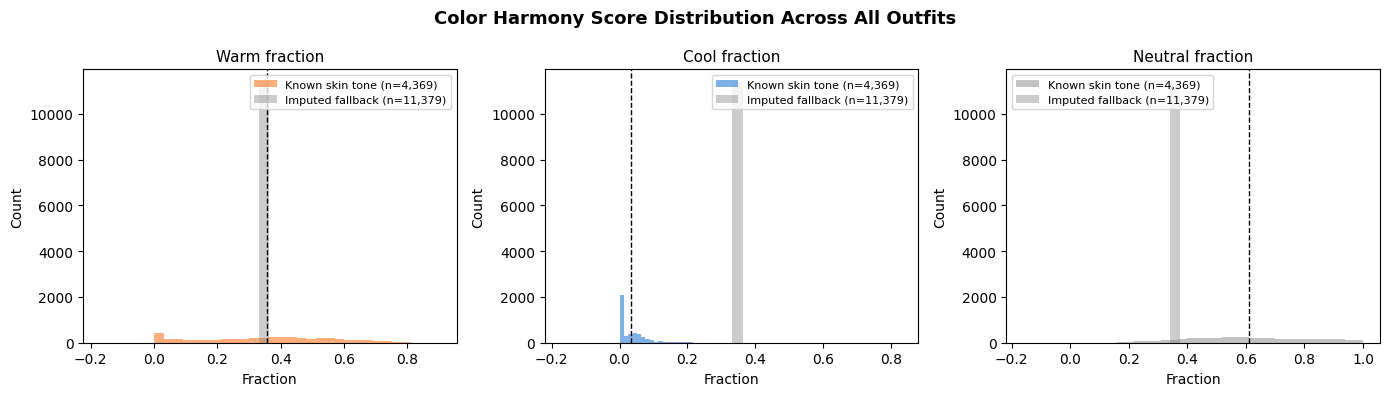

Saved to plots/08_harmony_distribution.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Color Harmony Score Distribution Across All Outfits', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['warm', 'cool', 'neutral'],
                          [TEMP_COLORS['warm'], TEMP_COLORS['cool'], TEMP_COLORS['neutral']]):
    known = df_h[df_h['was_imputed'] == 0][col]
    imputed = df_h[df_h['was_imputed'] == 1][col]
    ax.hist(known,   bins=30, alpha=0.7, color=color,   label=f'Known skin tone (n={len(known):,})')
    ax.hist(imputed, bins=30, alpha=0.4, color='gray',  label=f'Imputed fallback (n={len(imputed):,})')
    ax.set_title(f'{col.capitalize()} fraction', fontsize=11)
    ax.set_xlabel('Fraction')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.axvline(known.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={known.mean():.2f}')

plt.tight_layout()
plt.savefig('../plots/08_harmony_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to plots/08_harmony_distribution.png')

## 6. Integration with the Training Pipeline

The harmony scores are automatically picked up by `scripts/train.py` when `color_harmony_scores.json` exists. No extra CLI flags are needed.

**What changes in the model:**

```
Before:  phys_vec = [99 features]  →  phys_input_dim = 99
After:   phys_vec = [99 features] + [warm, cool, neutral, was_imputed]  →  phys_input_dim = 103
```

The `was_imputed` flag tells the model when the harmony score is a fallback (skin tone was unknown), so it can learn to down-weight those samples.

In [18]:
# Verify the integration: check phys_vec dimension with and without harmony
import torch
from torch.utils.data import DataLoader
from scripts.data_utils import O4UHybridDataset, collate_fn, load_harmony_scores
from scripts.config import FEATURES_DIR, TRAIN_IMPUTED_MANIFEST

df_train = pd.read_json(TRAIN_IMPUTED_MANIFEST)
df_train['binary_label'] = (df_train['score'].astype(float) >= 1.0).astype(int)
df_sample = df_train.head(16)

with open('../saved_models/phys_feature_cols.json') as f:
    feature_cols = json.load(f)

# The imputed manifest already contains the one-hot encoded columns
# (produced by the imputation pipeline). Verify they are present;
# if any are missing, fill with 0 to handle schema differences.
missing_cols = [c for c in feature_cols if c not in df_sample.columns]
if missing_cols:
    print(f'Filling {len(missing_cols)} missing feature columns with 0: {missing_cols[:5]}...')
    for col in missing_cols:
        df_sample = df_sample.copy()
        df_sample[col] = 0

harmony = load_harmony_scores(str(OUTPUT_PATH))

ds = O4UHybridDataset(df_sample, str(FEATURES_DIR), feature_cols, harmony_scores=harmony)
loader = DataLoader(ds, batch_size=4, collate_fn=collate_fn)
batch = next(iter(loader))
_, _, phys, _, _ = batch

print(f'phys_feature_cols count : {len(feature_cols)}')
print(f'harmony dims added      : 4  (warm, cool, neutral, was_imputed)')
print(f'phys_vec dim in batch   : {phys.shape[1]}')
print(f'phys_input_dim for model: {phys.shape[1]}')
assert phys.shape[1] == len(feature_cols) + 4, 'Dimension mismatch!'
print('\nIntegration check passed.')

 Checking/Caching 16 visual features...
phys_feature_cols count : 99
harmony dims added      : 4  (warm, cool, neutral, was_imputed)
phys_vec dim in batch   : 103
phys_input_dim for model: 103

Integration check passed.


## 7. Next Step

Color harmony preprocessing is complete. The before/after metric comparison 
(baseline vs + color harmony) is in **NB06 Evaluation — Step 8**.

Run **NB05 Training** next to retrain the model with the new harmony features.

## Summary

| Step | What happens |
|---|---|
| **Image → dominant colors** | k-means (k=3) on 64×64 resized garment images |
| **Color → temperature** | HSV hue classification: warm / cool / neutral |
| **Skin tone → recommendation** | CSV lookup: O4U `skin_color` → recommended color temperature profile |
| **Harmony score** | Dot-product similarity between outfit temperature and recommended profile, re-normalized to sum to 1 |
| **Missing skin tone** | Neutral fallback `[0.33, 0.33, 0.34]` + `was_imputed=1` flag |
| **Model integration** | 4 new dims appended to `phys_vec`: `[warm, cool, neutral, was_imputed]` |

The model now has an explicit signal for color-person compatibility, not just silhouette fit.